<a href="https://colab.research.google.com/github/emanuelmejia/course_time_series_python/blob/main/L01-Intro_TS/notebooks/L01_IntroTS(A).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
files.upload()

Saving pas.csv to pas (3).csv


{'pas (3).csv': b'Periodo,Pasajeros\r\n1,112\r\n2,118\r\n3,132\r\n4,129\r\n5,121\r\n6,135\r\n7,148\r\n8,148\r\n9,136\r\n10,119\r\n11,104\r\n12,118\r\n13,115\r\n14,126\r\n15,141\r\n16,135\r\n17,125\r\n18,149\r\n19,170\r\n20,170\r\n21,158\r\n22,133\r\n23,114\r\n24,140\r\n25,145\r\n26,150\r\n27,178\r\n28,163\r\n29,172\r\n30,178\r\n31,199\r\n32,199\r\n33,184\r\n34,162\r\n35,146\r\n36,166\r\n37,171\r\n38,180\r\n39,193\r\n40,181\r\n41,183\r\n42,218\r\n43,230\r\n44,242\r\n45,209\r\n46,191\r\n47,172\r\n48,194\r\n49,196\r\n50,196\r\n51,236\r\n52,235\r\n53,229\r\n54,243\r\n55,264\r\n56,272\r\n57,237\r\n58,211\r\n59,180\r\n60,201\r\n61,204\r\n62,188\r\n63,235\r\n64,227\r\n65,234\r\n66,264\r\n67,302\r\n68,293\r\n69,259\r\n70,229\r\n71,203\r\n72,229\r\n73,242\r\n74,233\r\n75,267\r\n76,269\r\n77,270\r\n78,315\r\n79,364\r\n80,347\r\n81,312\r\n82,274\r\n83,237\r\n84,278\r\n85,284\r\n86,277\r\n87,317\r\n88,313\r\n89,318\r\n90,374\r\n91,413\r\n92,405\r\n93,355\r\n94,306\r\n95,271\r\n96,306\r\n97,315\r\n

In [3]:
df = pd.read_csv("/content/pas.csv")
df

,Periodo,Pasajeros
0,1,112
1,2,118
2,3,132
3,4,129
4,5,121
...,...,...
139,140,606
140,141,508
141,142,461
142,143,390


In [4]:
df['Fecha'] = pd.period_range(start='1949-01', periods=len(df), freq='M')
df = df.set_index('Fecha')
df = df.drop(columns=['Periodo'])
df.head()

,Pasajeros
Fecha,
1949-01,112
1949-02,118
1949-03,132
1949-04,129
1949-05,121


In [5]:
# Modificaciones a la tabla para los gráficos

# Calcular Promedio móvil para 12 periodos (datos mensuales)
df['promMovil'] = df['Pasajeros'].rolling(window=12).mean()

# Extraer el mes del índice para el gráfico de cajas
df['Mes'] = df.index.month

df.tail()

,Pasajeros,promMovil,Mes
Fecha,,,
1960-08,606,463.333333,8
1960-09,508,467.083333,9
1960-10,461,471.583333,10
1960-11,390,473.916667,11
1960-12,432,476.166667,12


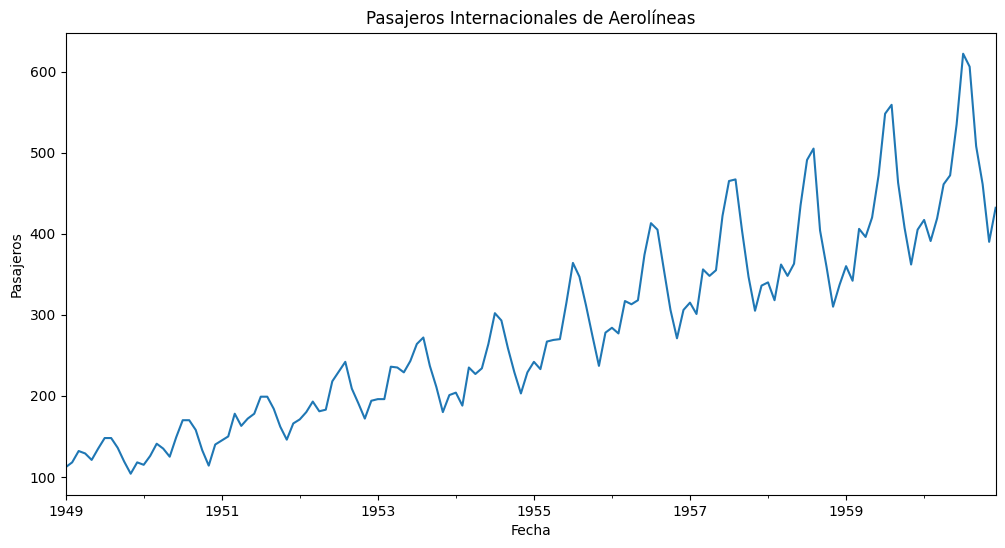

In [6]:
plt.figure(figsize=(12, 6))
df['Pasajeros'].plot()
plt.title('Pasajeros Internacionales de Aerolíneas')
plt.xlabel('Fecha')
plt.ylabel('Pasajeros')
plt.show()

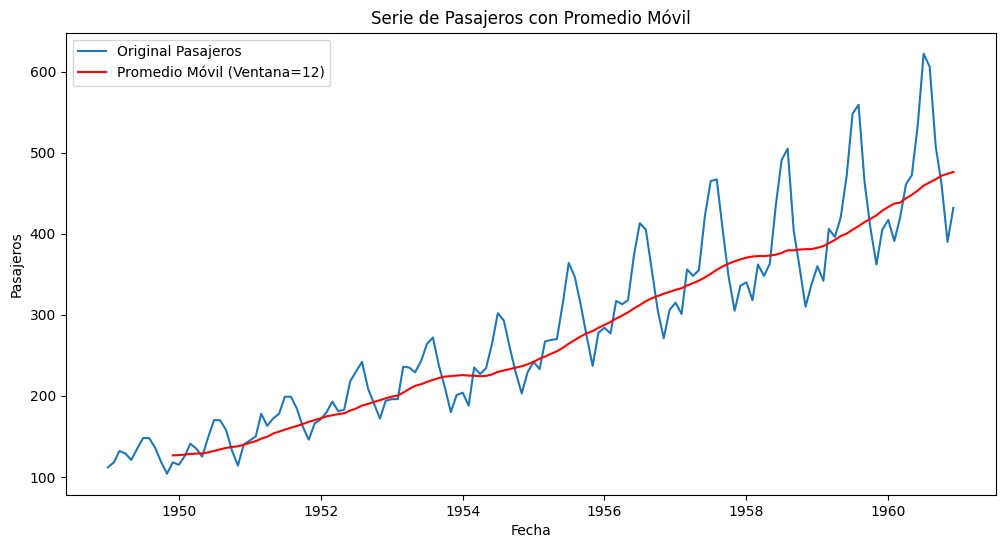

In [7]:
# Graficar serie original con promedio Móvil
plt.figure(figsize=(12, 6))
plt.plot(df['Pasajeros'].index.to_timestamp(), df['Pasajeros'], label='Original Pasajeros')
plt.plot(df['promMovil'].index.to_timestamp(), df['promMovil'], label='Promedio Móvil (Ventana=12)', color='red')
plt.title('Serie de Pasajeros con Promedio Móvil')
plt.xlabel('Fecha')
plt.ylabel('Pasajeros')
plt.legend()

plt.show()

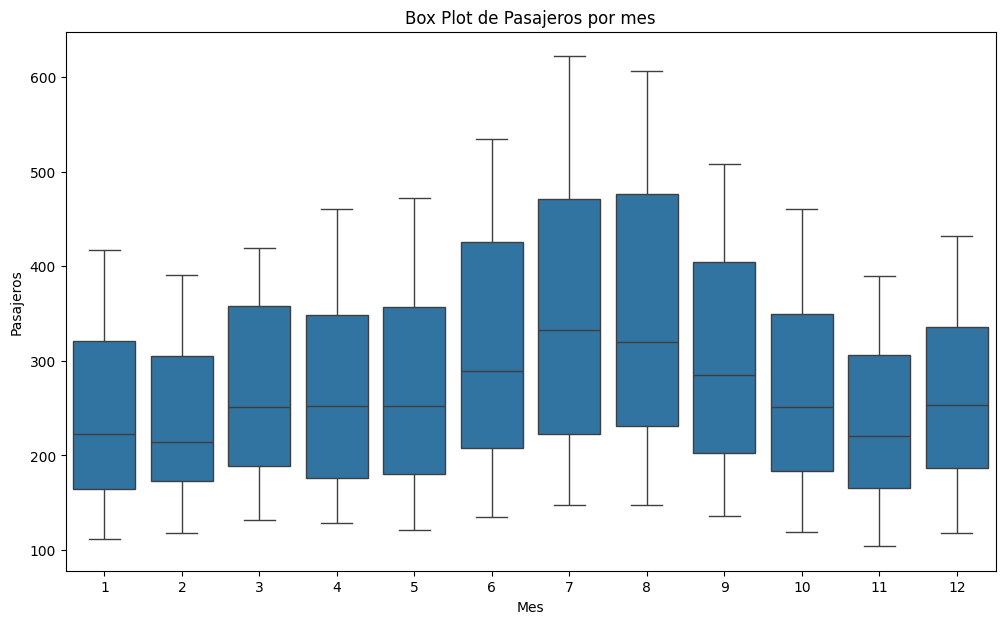

In [8]:
# Crear el gráfico de cajas
plt.figure(figsize=(12, 7))
sns.boxplot(x='Mes', y='Pasajeros', data=df)
plt.title('Box Plot de Pasajeros por mes')
plt.xlabel('Mes')
plt.ylabel('Pasajeros')
plt.show()

In [9]:
# Variables de formato para gráficos

colorBase= 'aqua'
fontEti = {'family':'serif','color':colorBase,'size': 15, 'fontweight': 'bold'}
fontTit = {'family':'serif','color':colorBase,'size': 25, 'fontweight': 'bold'}
fontSub = {'family':'serif','color':'lightgray','size': 18, 'fontstyle': 'italic'}

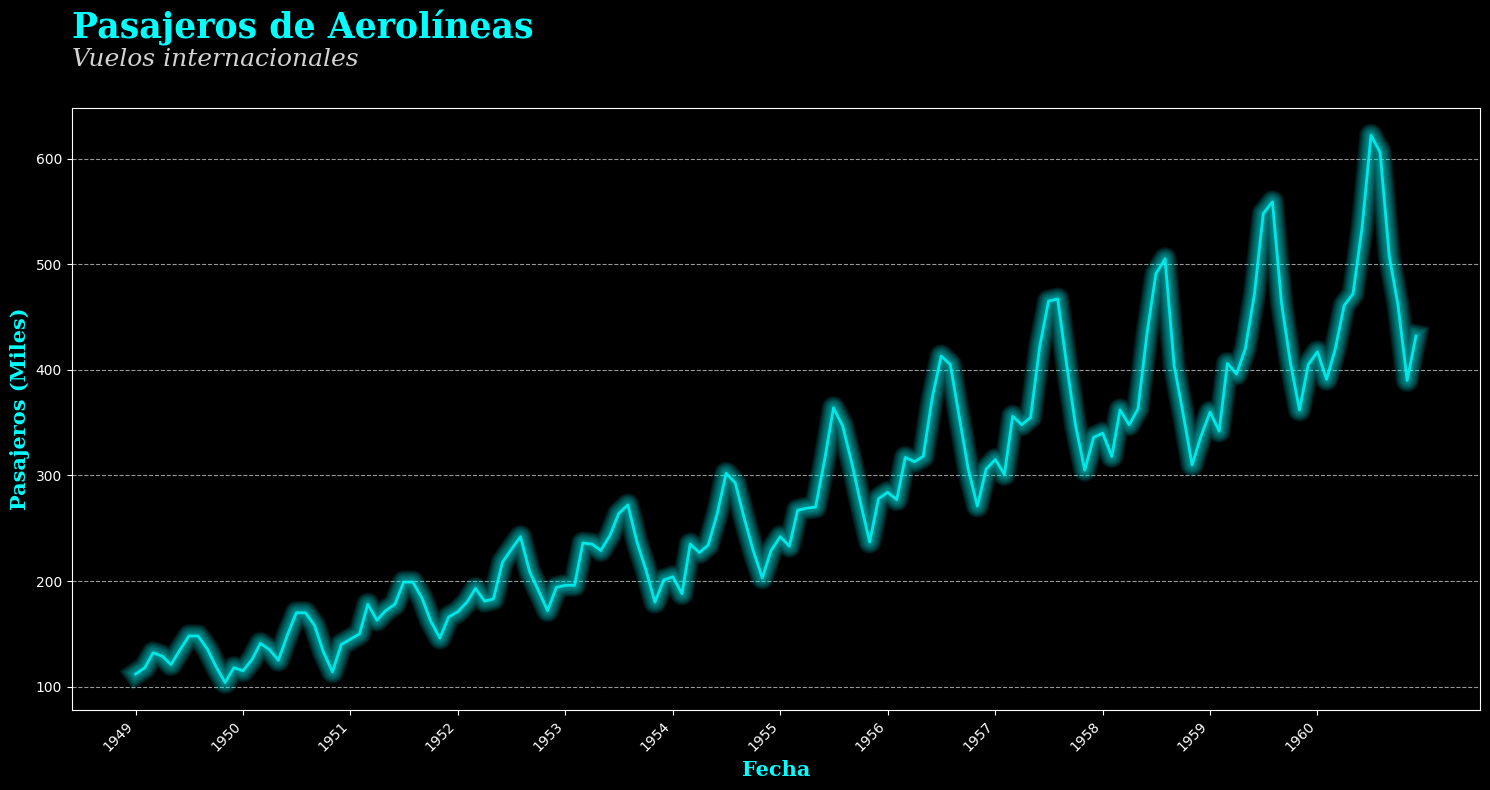

In [10]:
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(15, 8))

# Datos para efecto de brillo
nGlows = 10
lwBase = 2
opacityBase = 0.8

# Graficar varias líneas con diferente espesor/opacidad para dar brillo
for i in range(1, nGlows + 1):
    ax.plot(df.index.to_timestamp(),
            df['Pasajeros'],
            color = colorBase,
            linewidth = lwBase + (i * 1.5),
            alpha = opacityBase / nGlows)

# Graficar la línea principal encima
ax.plot(df.index.to_timestamp(),
        df['Pasajeros'],
        # marker='o',
        linewidth = lwBase,
        color = colorBase,
        alpha= opacityBase)


# Formato de etiquetas
ax.set_title('Pasajeros de Aerolíneas', fontdict = fontTit, loc='left', pad=50)
ax.text(0.0, 1.1, 'Vuelos internacionales', transform=ax.transAxes,
        ha='left', va='top', fontdict=fontSub)
ax.set_xlabel('Fecha', fontdict = fontEti)
ax.set_ylabel('Pasajeros (Miles)', fontdict = fontEti)
ax.set_xticks(df.index.to_timestamp()[::12]) # ticks para cada uno de los años
ax.set_xticklabels(df.index.to_timestamp()[::12].strftime('%Y'), rotation=45, ha='right') # etiquetar cada año y rotar 45grados

# Estilo al enrejado
ax.grid(False, axis = 'x')
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout() # Prevenir traslape de etiquetas o datos
plt.show()

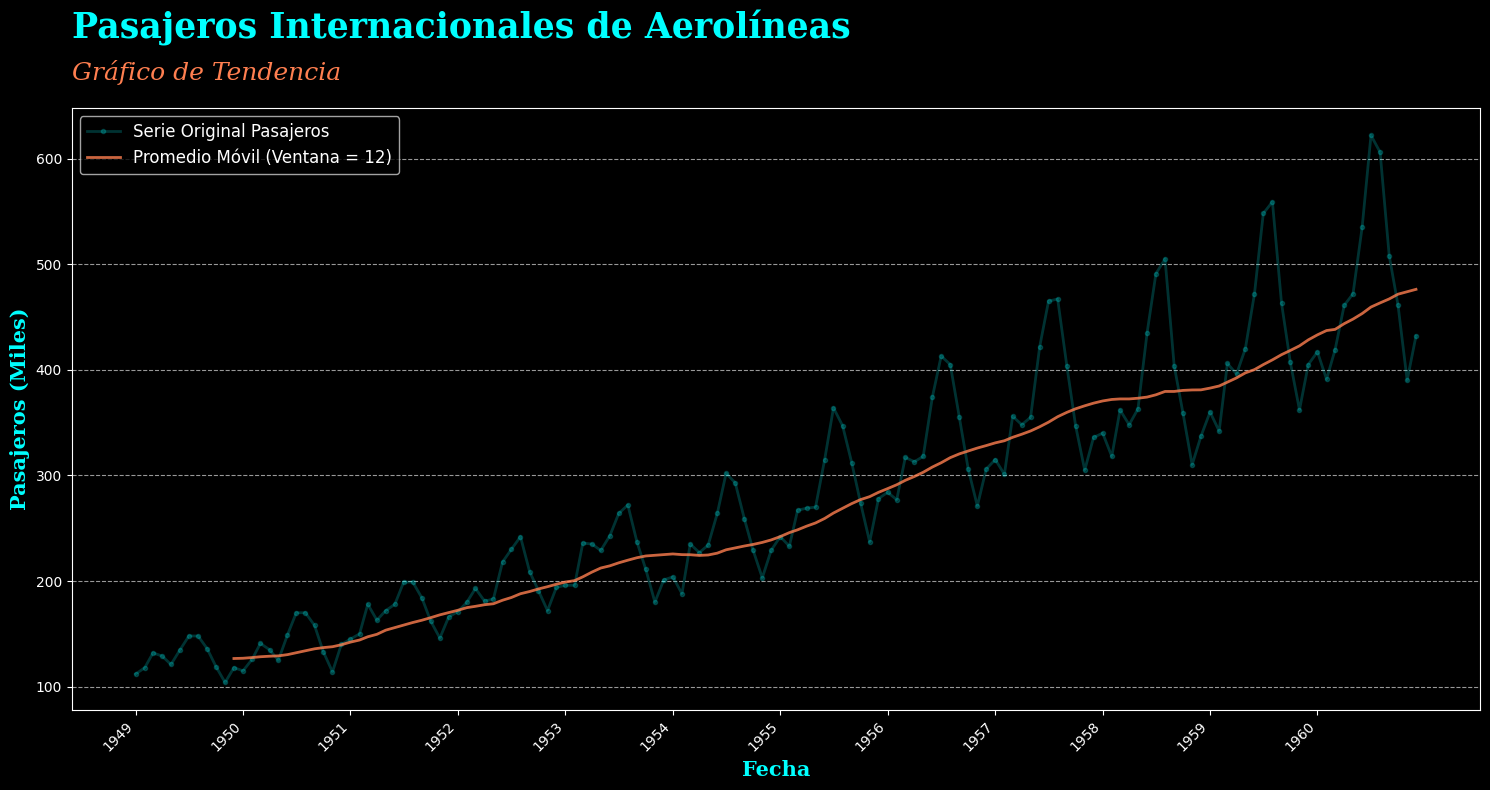

In [11]:
colorProm= 'coral'
fontSub['color'] = colorProm

fig, ax = plt.subplots(figsize=(15, 8))

# Graficar la línea principal
ax.plot(df.index.to_timestamp(),
        df['Pasajeros'],
        label='Serie Original Pasajeros',
        marker='.',
        linewidth = lwBase,
        color = colorBase,
        alpha= 0.2)

# Graficar la línea de promedio Móvil
ax.plot(df.index.to_timestamp(),
        df['promMovil'],
        label='Promedio Móvil (Ventana = 12)',
        linewidth = lwBase,
        color = colorProm,
        alpha= opacityBase)

# Formato de etiquetas
ax.set_title('Pasajeros Internacionales de Aerolíneas', fontdict = fontTit, loc='left', pad=50)
ax.text(0.0, 1.08, 'Gráfico de Tendencia', transform=ax.transAxes,
        ha='left', va='top', fontdict=fontSub)
ax.set_xlabel('Fecha', fontdict = fontEti)
ax.set_ylabel('Pasajeros (Miles)', fontdict = fontEti)
ax.set_xticks(df.index.to_timestamp()[::12]) # ticks para cada uno de los años
ax.set_xticklabels(df.index.to_timestamp()[::12].strftime('%Y'), rotation=45, ha='right') # etiquetar cada año y rotar 45grados

# Estilo al enrejado
ax.grid(False, axis = 'x')
ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.legend(fontsize='large')
plt.tight_layout() # Prevenir traslape de etiquetas o datos
plt.show()

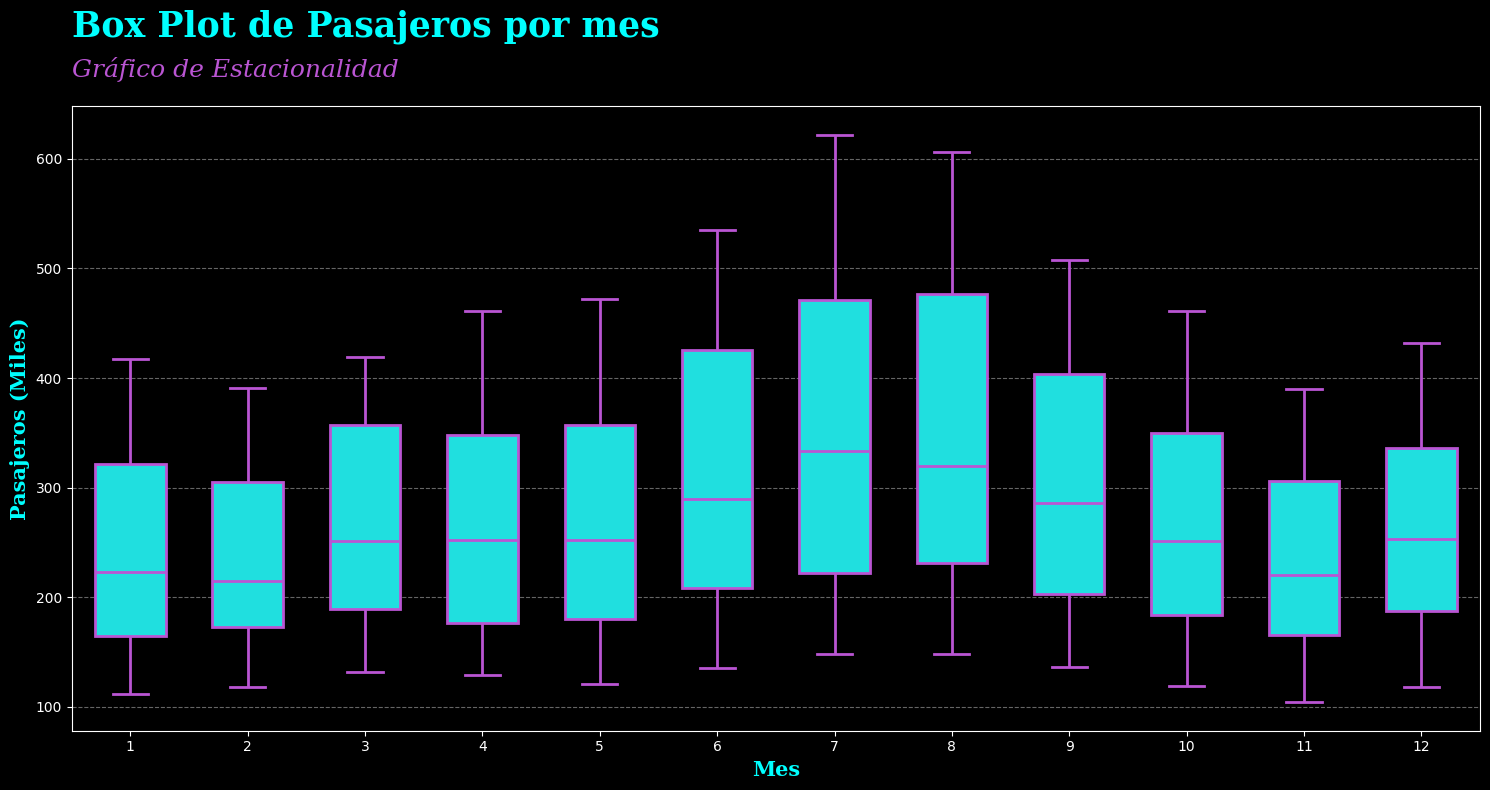

In [12]:
colorBox = 'mediumorchid'
fontSub['color'] = colorBox

# Crear el gráfico de cajas

fig, ax = plt.subplots(figsize=(15, 8))

sns.boxplot(x='Mes', y='Pasajeros', data=df,
            color = colorBase, linecolor = colorBox,
            linewidth= 2, width = 0.6)

# Formato de etiquetas
ax.set_title('Box Plot de Pasajeros por mes', fontdict = fontTit, loc='left', pad=50)
ax.text(0.0, 1.08, 'Gráfico de Estacionalidad', transform=ax.transAxes,
        ha='left', va='top', fontdict=fontSub)
ax.set_xlabel('Mes', fontdict = fontEti)
ax.set_ylabel('Pasajeros (Miles)', fontdict = fontEti)

# Estilo al enrejado
ax.grid(False, axis = 'x')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout() # Prevenir traslape de etiquetas o datos
plt.show()

In [13]:
datosJulio = df[df['Mes'] == 7]["Pasajeros"]
datosJulio

,Pasajeros
Fecha,
1949-07,148
1950-07,170
1951-07,199
1952-07,230
1953-07,264
1954-07,302
1955-07,364
1956-07,413
1957-07,465


In [14]:
datosJulio.sort_values(ascending=False)

,Pasajeros
Fecha,
1960-07,622
1959-07,548
1958-07,491
1957-07,465
1956-07,413
1955-07,364
1954-07,302
1953-07,264
1952-07,230


In [15]:
# Calcular valores caja para mes Julio
q1Julio = datosJulio.quantile(0.25)
medianaJulio = datosJulio.median()
q3Julio = datosJulio.quantile(0.75)

# Calcular IQR y bigotes para mes Julio
ranIntercuartil = q3Julio - q1Julio
limInf = q1Julio - 1.5 * ranIntercuartil
limSup = q3Julio + 1.5 * ranIntercuartil
bigoteInf = datosJulio[datosJulio >= limInf].min()
bigoteSup = datosJulio[datosJulio <= limSup].max()

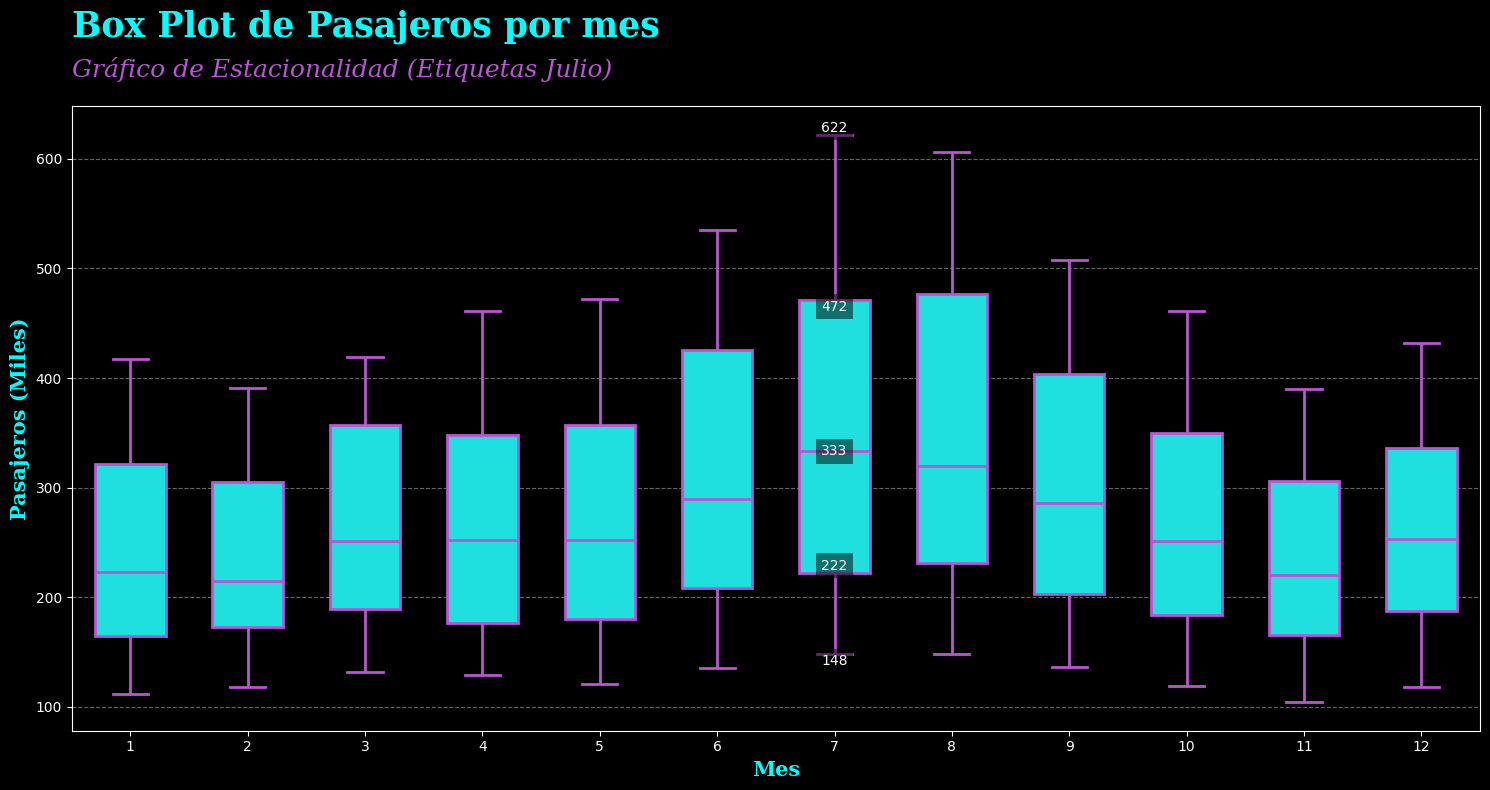

In [16]:
colorBox = 'mediumorchid'
fontSub['color'] = colorBox

# Crear el gráfico de cajas

fig, ax = plt.subplots(figsize=(15, 8))

sns.boxplot(x='Mes', y='Pasajeros', data=df,
            color = colorBase, linecolor = colorBox,
            linewidth= 2, width = 0.6)

# Formato de etiquetas
ax.set_title('Box Plot de Pasajeros por mes', fontdict = fontTit, loc='left', pad=50)
ax.text(0.0, 1.08, 'Gráfico de Estacionalidad (Etiquetas Julio)', transform=ax.transAxes,
        ha='left', va='top', fontdict=fontSub)
ax.set_xlabel('Mes', fontdict = fontEti)
ax.set_ylabel('Pasajeros (Miles)', fontdict = fontEti)

# La posición para el mes de Julio en las etiquetas (índice 0)
posEtiquetas = 6

# Agregar etiquetas para mes Julio
ax.text(posEtiquetas, bigoteSup, f'{bigoteSup:.0f}', ha='center', va='bottom', color='white', fontsize=10,
        bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))
ax.text(posEtiquetas, q3Julio, f'{q3Julio:.0f}', ha='center', va='top', color='white', fontsize=10,
        bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))
ax.text(posEtiquetas, medianaJulio, f'{medianaJulio:.0f}', ha='center', va='center', color='white', fontsize=10,
        bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))
ax.text(posEtiquetas, q1Julio, f'{q1Julio:.0f}', ha='center', va='bottom', color='white', fontsize=10,
        bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))
ax.text(posEtiquetas, bigoteInf, f'{bigoteInf:.0f}', ha='center', va='top', color='white', fontsize=10,
        bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))

# Estilo a la tabla
ax.grid(False, axis = 'x')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout() # Prevenir traslape de etiquetas o datos
plt.show()